In [11]:
import praw
from datetime import datetime
import time
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
reddit = praw.Reddit(user_agent=True, client_id="",
                     client_secret = "", username="", 
                     password="")

In [7]:
url ="https://www.reddit.com/r/tbilisi/comments/1kgsrmt/is_tbilisi_safe_ive_heard_that_there_are_group_of/"

In [9]:
post = reddit.submission(url=url)
print(post.title)
print(post.selftext)

Is Tbilisi safe? I’ve heard that there are group of pickpockets and police also doesn’t help.
Teenage kids are in on this as well 


In [5]:
post.comments.replace_more(limit=None, threshold=0) #loading all nested comments

def print_comments(comments, indent=0): #fetches all the comments
    for comment in comments:
        print("  " * indent + f"Author: {comment.author}")
        print("  " * indent + "  " * indent + f"Body: {comment.body}")
        if hasattr(comment, "replies"):   #checks for a child comment
            print_comments(comment.replies, indent + 1)

#print_comments(post.comments)

NameError: name 'post' is not defined

In [13]:
all_comments = post.comments.list()
total_comments = len(all_comments)
print(total_comments)

29


In [15]:
def unix_to_datetime(unix_time):
    """Convert Unix timestamp to datetime string."""
    return datetime.fromtimestamp(unix_time).strftime('%Y-%m-%d %H:%M:%S')

In [7]:
def pull_reddit_data(
    reddit,
    subreddit_names,
    keywords,
    min_upvotes,
    start_date,
    end_date,
    min_comment_upvotes,
    max_posts=5000
):
    """
    Pull posts and comments from multiple Reddit subreddits based on criteria and store in DataFrame.
    
    Parameters:
    - reddit: PRAW Reddit instance
    - subreddit_names: List of subreddit names to search
    - keywords: List of keywords to search for in posts
    - min_upvotes: Minimum upvotes for posts
    - start_date: Unix timestamp for earliest post
    - end_date: Unix timestamp for latest post
    - min_comment_upvotes: Minimum upvotes for comments
    - max_posts: Maximum number of posts to retrieve per subreddit
    
    Returns:
    - DataFrame containing posts and comments data
    """
    # Initialize list to store data
    data = []
    
    # Convert keywords to lowercase for case-insensitive search
    keywords = [k.lower() for k in keywords]
    
    # Iterate over each subreddit
    for subreddit_name in subreddit_names:
        try:
            subreddit = reddit.subreddit(subreddit_name)
            
            # Search posts
            for submission in subreddit.search(
                ' '.join(keywords),
                sort='relevance',
                time_filter='all',
                limit=max_posts
            ):
                # Check post criteria
                post_time = submission.created_utc
                if (submission.ups >= min_upvotes and
                    start_date <= post_time <= end_date):
                    
                    # Store post data
                    post_data = {
                        'type': 'post',
                        'id': submission.id,
                        'title': submission.title,
                        'text': submission.selftext,
                        'url': submission.url,
                        'upvotes': submission.ups,
                        'created_utc': unix_to_datetime(post_time),
                        'author': submission.author.name if submission.author else '[deleted]',
                        'subreddit': submission.subreddit.display_name
                    }
                    data.append(post_data)
                    
                    # Get all comments
                    submission.comments.replace_more(limit=None)
                    for comment in submission.comments.list():
                        if (comment.ups >= min_comment_upvotes and
                        any(keyword in comment.body.lower() for keyword in keywords)):
                            comment_data = {
                                'type': 'comment',
                                'id': comment.id,
                                'title': '',
                                'text': comment.body,
                                'url': f'https://reddit.com{comment.permalink}',
                                'upvotes': comment.ups,
                                'created_utc': unix_to_datetime(comment.created_utc),
                                'author': comment.author.name if comment.author else '[deleted]',
                                'subreddit': submission.subreddit.display_name,
                                'parent_post_id': submission.id
                            }
                            data.append(comment_data)
                
                # Respect Reddit API rate limits
                time.sleep(1)
            
        except Exception as e:
            print(f"Error processing subreddit {subreddit_name}: {e}")
            continue
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Reorder columns
    columns = [
        'type', 'id', 'parent_post_id', 'subreddit', 'title', 'text',
        'url', 'upvotes', 'created_utc', 'author'
    ]
    # Ensure all columns exist
    for col in columns:
        if col not in df.columns:
            df[col] = ''
    
    df = df[columns]
    
    return df

In [17]:
def save_to_csv(df, filename):
    """Save DataFrame to CSV file."""
    df.to_csv(filename, index=False, encoding='utf-8')
    print(f"Data saved to {filename}")

In [31]:
if __name__ == "__main__":
    # Assuming reddit instance is already created
    # reddit = praw.Reddit(client_id='your_client_id', ...)
    
    # Example parameters
    subreddit_names = [
    'wallstreetbets',
    'investing',
    'stocks',
    'valueinvesting',
    'StockMarket',
    'options',
    'ETFs'
    ]
    keywords = [
    'HD',                   # Ticker symbol
    'Home Depot',           # Company name
    'HOME DEPOT',           # all caps
    'The Home Depot, Inc.', # Full company name
    'Home Depot stock',     # Common phrase
    'HD stock',             # Common phrase
    '$HD',                   # Ticker with dollar sign
    'Ted Decker',           # CEO name
    'Home improvement HD',  # Industry term
    'Retail HD',            # Industry term
    'DIY HD',               # Related term
    'Construction materials HD', # Related term
    'Home Depot earnings',  # Financial reports
    'HD earnings',          # Financial reports
    'Home Depot news',      # General news
    'HD news',              # General news
    'Home Depot price',     # Stock price discussions
    'HD price',             # Stock price discussions
    'Home Depot dividend',  # Dividend discussions
    'HD dividend',          # Dividend discussions
    ]
    min_upvotes = 10  # Minimum post upvotes
    min_comment_upvotes = 5  # Minimum comment upvotes
    start_date = int(datetime(2015, 1, 1).timestamp())  
    end_date = int(datetime(2025, 5, 16).timestamp())  
    output_file = 'HD1.csv'
        # Pull data
    df = pull_reddit_data(
        reddit=reddit,
        subreddit_names=subreddit_names,
        keywords=keywords,
        min_upvotes=min_upvotes,
        start_date=start_date,
        end_date=end_date,
        min_comment_upvotes=min_comment_upvotes
    )
    
    # Save to CSV
    save_to_csv(df, output_file)

Data saved to HD1.csv


In [19]:
def analyze_sentiment(df):
    """
    Perform sentiment analysis on the text column of the DataFrame using VADER.
    
    Parameters:
    - df: DataFrame containing Reddit posts and comments
    
    Returns:
    - DataFrame with added sentiment score columns
    """
    # Initialize VADER sentiment analyzer
    analyzer = SentimentIntensityAnalyzer()
    
    # Identify text column (try 'text', 'comment', 'body', or first string column)
    text_col = None
    for col in ['text', 'comment', 'body']:
        if col in df.columns:
            text_col = col
            break
    if text_col is None:
        # Fallback: use first column with string/object dtype
        for col in df.columns:
            if df[col].dtype == 'object':
                text_col = col
                break
    if text_col is None:
        raise ValueError("No suitable text column found in DataFrame")
    
    print(f"Using column '{text_col}' for sentiment analysis")
    
    # Function to get sentiment scores
    def get_sentiment_scores(text):
        if pd.isna(text) or str(text).strip() == '':
            return {'pos': 0.0, 'neu': 0.0, 'neg': 0.0, 'compound': 0.0}
        scores = analyzer.polarity_scores(str(text))
        return {
            'pos': scores['pos'],    # Correct key
            'neu': scores['neu'],    # Correct key
            'neg': scores['neg'],    # Correct key
            'compound': scores['compound']
        }
    
    # Apply sentiment analysis to the text column
    sentiment_scores = df[text_col].apply(get_sentiment_scores)
    
    # Convert sentiment scores to separate columns
    df['sentiment_positive'] = sentiment_scores.apply(lambda x: x['pos'])
    df['sentiment_neutral'] = sentiment_scores.apply(lambda x: x['neu'])
    df['sentiment_negative'] = sentiment_scores.apply(lambda x: x['neg'])
    df['sentiment_compound'] = sentiment_scores.apply(lambda x: x['compound'])
    
    return df

In [23]:
# Main execution
if __name__ == "__main__":
    # Load the Reddit data CSV (similar to tesla = pd.read_csv("TSLA.csv"))
    reddit_data = pd.read_csv("GTLB/GTLB2.csv")
    
    # Perform sentiment analysis
    reddit_data_with_sentiment = analyze_sentiment(reddit_data)
    
    # Define output file
    output_file = "GTLB/GTLB2.csv"
    
    # Save results
    save_to_csv(reddit_data_with_sentiment, output_file)
    
    # Print summary
    print(f"Processed {len(reddit_data_with_sentiment)} items (posts and comments) "
          f"with sentiment analysis.")
    print("New columns added: sentiment_positive, sentiment_neutral, "
          "sentiment_negative, sentiment_compound")

Using column 'text' for sentiment analysis
Data saved to GTLB/GTLB2.csv
Processed 212 items (posts and comments) with sentiment analysis.
New columns added: sentiment_positive, sentiment_neutral, sentiment_negative, sentiment_compound


In [15]:
pd.read_csv("sp100_sentiment.csv").columns

Index(['ticker', 'type', 'id', 'parent_post_id', 'subreddit', 'title', 'text',
       'url', 'upvotes', 'created_utc', 'author', 'word_count',
       'author_created_utc', 'sentiment_positive', 'sentiment_neutral',
       'sentiment_negative', 'sentiment_compound'],
      dtype='object')

In [45]:
def get_sentiment_category(compound_score):
    """
    Categorize sentiment based on compound score.
    
    Parameters:
    - compound_score: Float, VADER compound score
    
    Returns:
    - String: 'Positive', 'Neutral', or 'Negative'
    """
    if compound_score > 0.05:
        return 'Positive'
    elif compound_score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

def compute_daily_sentiment(file_path, stock_name):
    """
    Compute average sentiment per day for a stock and create a table.
    
    Parameters:
    - file_path: Path to the sentiment analysis CSV file
    - stock_name: Name of the stock (e.g., 'PLTR')
    
    Returns:
    - DataFrame: Table with daily sentiment metrics
    """
    try:
        # Load CSV
        df = pd.read_csv(file_path)
        
        # Check for required columns
        if 'sentiment_compound' not in df.columns or 'created_utc' not in df.columns:
            raise ValueError("CSV must contain 'sentiment_compound' and 'created_utc' columns")
        
        # Convert created_utc to datetime and extract date
        df['created_utc'] = pd.to_datetime(df['created_utc'])
        df['date'] = df['created_utc'].dt.date
        
        # Group by date and compute average compound score
        daily_sentiment = df.groupby('date')['sentiment_compound'].mean().reset_index()
        
        # Add sentiment category based on average compound score
        daily_sentiment['Sentiment_Category'] = daily_sentiment['sentiment_compound'].apply(get_sentiment_category)
        
        # Rename columns for clarity
        daily_sentiment.columns = ['Date', 'Average_Compound_Score', 'Sentiment_Category']
        
        # Add stock name
        daily_sentiment['Stock'] = stock_name
        
        # Reorder columns
        daily_sentiment = daily_sentiment[['Stock', 'Date', 'Average_Compound_Score', 'Sentiment_Category']]
        
        # Sort by date
        daily_sentiment = daily_sentiment.sort_values(by='Date')
        
        return daily_sentiment
    
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return pd.DataFrame()

def save_and_display_table(df, output_file):
    """
    Save the daily sentiment table to CSV and display it.
    
    Parameters:
    - df: DataFrame with daily sentiment table
    - output_file: Path to save the CSV
    """
    if df.empty:
        print("No data to save")
        return
    
    # Ensure .csv extension
    if not output_file.endswith('.csv'):
        output_file = output_file + '.csv'
    
    # Save to CSV
    try:
        df.to_csv(output_file, index=False, encoding='utf-8')
        print(f"Daily sentiment table saved to {output_file}")
    except Exception as e:
        print(f"Error saving CSV file: {e}")
        return
    
    # Display table
    print("\nDaily Sentiment Table:")
    print(df.to_string(index=False, float_format='%.4f'))

# Main execution
if __name__ == "__main__":
    # Input file and stock name
    input_file = "NVDA_sentiment.csv"  # Change to your file, e.g., "TSLA_with_sentiment.csv"
    stock_name = "NVDA"
    
    # Compute daily sentiment
    daily_sentiment_table = compute_daily_sentiment(input_file, stock_name)
    
    # Save and display
    output_file = f"{stock_name}_daily_sentiment.csv"
    save_and_display_table(daily_sentiment_table, output_file)

Daily sentiment table saved to NVDA_daily_sentiment.csv

Daily Sentiment Table:
Stock       Date  Average_Compound_Score Sentiment_Category
 NVDA 2025-04-02                  0.9746           Positive
 NVDA 2025-04-03                 -0.0683           Negative
 NVDA 2025-04-04                  0.5773           Positive
 NVDA 2025-04-05                  0.1835           Positive
 NVDA 2025-04-06                  0.9896           Positive
 NVDA 2025-04-07                  0.9190           Positive
 NVDA 2025-04-08                  0.5141           Positive
 NVDA 2025-04-09                 -0.1887           Negative
 NVDA 2025-04-10                  0.2910           Positive
 NVDA 2025-04-11                  0.8442           Positive
 NVDA 2025-04-12                  0.8047           Positive
 NVDA 2025-04-13                  0.9454           Positive
 NVDA 2025-04-14                  0.2107           Positive
 NVDA 2025-04-15                  0.3213           Positive
 NVDA 2025-04-16    

In [47]:
import matplotlib.pyplot as plt

In [161]:
NVDA = pd.read_csv("NVDA_daily_sentiment.csv",index_col=[1])

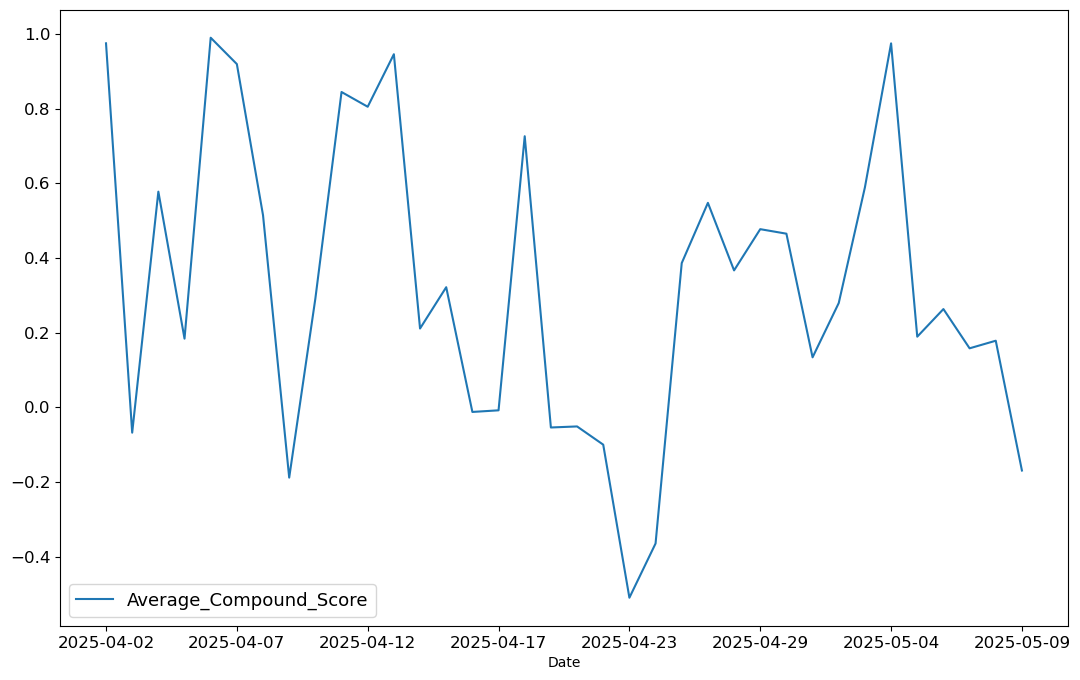

In [163]:
NVDA["Average_Compound_Score"].plot(figsize = (13,8), fontsize=12)
plt.legend(fontsize=13)
plt.show()

In [151]:
import yfinance as yf

In [181]:
NVDA_returns= yf.download("NVDA", start = "2025-04-01", end= "2025-05-08")

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NVDA']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


In [155]:
NVDA_returns

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,,
